# 第10章 深度学习处理实践序列

**本章包括以下内容**:
- 处理时间序列数据的机器学习任务示例
- 理解循环神经网络
- 将循环神经网络应用于温度预测示例
- 循环神经网络的高级用法

## 10.1 不同类型的时间序列任务

**时间序列**（timeseries）是指定期测量获得的任意数据，比如每日股价。处理时间序列需要了解系统的**动力学**（dynamics），包括系统的周期性循环、系统随时间变化、系统的周期规律与突然激增等。

最常见的时间序列任务是预测，这也是本节的重点内容。

> 除了预测，时间序列还可以做其他的有ixie事情：
> - **分类**：已知一个网游从冲浪时间序列，判断该网友是否是机器人。
> - **事件检测** 
> - **异常检测**

**循环神经网络**（recurrent neural network, RNN）

## 10.2 温度预测示例

已知由屋顶传感器测量的每小时气压、湿度等数据的时间序列，预测 24 小时之后的温度。

In [1]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2025-02-19 10:12:40--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.234.168, 52.217.73.230, 52.216.94.141, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.234.168|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M   706KB/s    in 24s     

2025-02-19 10:13:04 (563 KB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


代码清单 10-1 查看耶拿天气数据集

In [1]:
import os
fname = os.path.join("jena_climate_2009_2016.csv")
with open(fname) as f:
    data = f.read()
    lines = data.split("\n")
    header = lines[0].split(",")
    lines = lines[1:]
    print(header)
    print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


接下来将 420451 行数据转换为 NumPy 数组。

代码清单 10-2 解析数据

In [2]:
import numpy as np
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header)-1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

代码清单 10-3 绘制温度时间序列

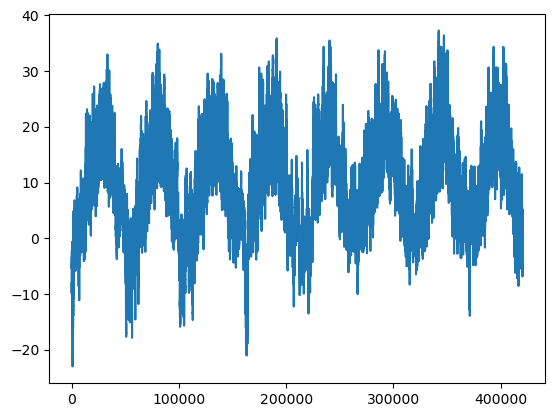

In [3]:
import matplotlib.pyplot as plt
plt.plot(range(len(temperature)), temperature)

这个数据集中，每 10 分钟记录一次数据，每天记录 144 个数据点

代码清单 10-4 绘制前 10 天的温度时间序列

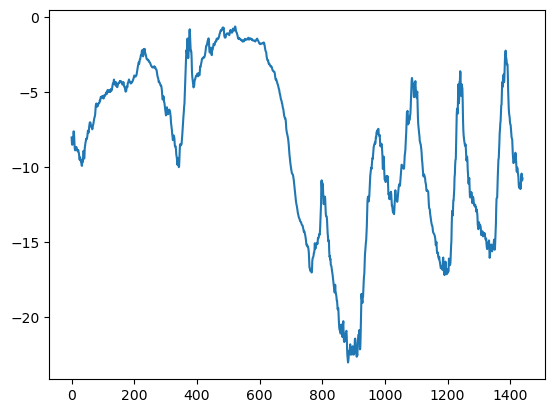

In [4]:
plt.plot(range(1440), temperature[:1440])

处理时间序列数据时，验证数据和测试数据  应该比训练数据更靠后,因为你是要根据过去预测未来。在本次示例中，我们将前 10% 的数据用于训练，随后 25% 用于验证，最后 25% 用于测试。

代码清单 10-5 计算用于训练、验证和测试的样本数

In [5]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

### 10.2.1 准备数据

代码清单 10-6 数据规范化

In [6]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

理解 `timeseries_dataset_from_array()`：举个例子，对于 `data = [0, 1, 2, 3, 4, 5, 6]` 和 `sequence_length = 3`，`timeseries_dataset_from_array()` 将生成一下样本：`[0, 1, 2]`，`[1, 2, 3]`，`[2, 3, 4]`，`[3, 4, 5]`，`[4, 5, 6]`

代码清单 10-7 创建 3 个数据集，分别用于训练、验证和测试

In [8]:
from tensorflow import keras

# 观测数据的采样频率是每小时一个数据点，也就是说，每 6 个数据点保留一个
sampling_rate = 6
# 给定过去 5 天（120 小时）的观测数据
sequence_length = 120
# 序列的目标是结束 24 小时之后的温度
delay = sampling_rate * (sequence_length + 24 -1)
batch_size = 256

train_dataset = keras.preprocessing.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.preprocessing.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples) 

test_dataset = keras.preprocessing.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

2025-02-19 16:30:01.772089: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-02-19 16:30:01.773167: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2025-02-19 16:30:01.802599: E tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:927] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-02-19 16:30:01.802644: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA GeForce RTX 3060 Laptop GPU computeCapability: 8.6
coreClock: 1.425GHz coreCount: 30 deviceMemorySize: 6.00GiB deviceMemoryBandwidth: 312.97GiB/s
2025-02-19 16:30:01.802683: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2025-02-19 16:30:01.804109: I tensorflow/stream_exec

每个数据集都会生成一个元组 `(samples, targets)`

代码清单 10-8 产看一个数据集的输出

In [9]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


2025-02-19 16:30:05.281626: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2025-02-19 16:30:05.284291: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 3293815000 Hz


### 10.2.2 基于常识、不使用机器学习的基准

假设：温度时间序列是连续的，即明天的温度很可能接近今天的温度，并且具有每天的周期性变化。

代码清单 10-9 计算基于常识的基准的 MAE

In [10]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen
        
print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


### 10.2.3 基本的机器学习模型

代码清单 10-10 训练并评估一个密集连接模型

In [11]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs) 
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
    ]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10


2025-02-19 16:30:26.507592: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.10
2025-02-19 16:30:27.218976: W tensorflow/core/framework/op_kernel.cc:1763] OP_REQUIRES failed at cwise_op_gpu_base.cc:89 : Internal: Failed to load in-memory CUBIN: CUDA_ERROR_NO_BINARY_FOR_GPU: no kernel image is available for execution on the device


InternalError:  Failed to load in-memory CUBIN: CUDA_ERROR_NO_BINARY_FOR_GPU: no kernel image is available for execution on the device
	 [[node Abs (defined at tmp/ipykernel_84710/1233545388.py:13) ]] [Op:__inference_train_function_9845]

Function call stack:
train_function


代码清单 10-11 绘制结果

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

可以看到这个模型再验证数据机上的表现是不太好的。

### 10.2.4 一维卷积模型

In [13]:
from tensorflow import keras
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")
x = layers.MaxPool1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
    "jena_conv.keras", save_best_only=True)
] 
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

TypeError: Inputs to a layer should be tensors. Got: <tensorflow.python.keras.layers.convolutional.Conv1D object at 0x7f7370ecda90>

这个模型的性能甚至比密集连接模型更差，可能是因为两个原因：
- 天气数据并不完全遵循平移不变假设。天气数据在每天相同时间点具有相似属性，在同一天的不同时间点却相差很大。
- 数据的顺序很重要。而卷积神经网络无法利用利用数据的顺序特征。

### 10.2.5 第一个 RNN 基准

RNN 是一种专门处理序列数据的神经网络架构，其中**长短期记忆**（Long Short Term Memory, LSTM）层长期以来一直很受欢迎。

代码清单 10-12 基于 LSTM 的简单模型

In [21]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras",
                                    save_best_only=True)
    ] 
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset, epochs=10, validation_data=val_dataset, callbacks=callbacks)
model = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

NotImplementedError: Cannot convert a symbolic Tensor (lstm_4/strided_slice:0) to a numpy array. This error may indicate that you're trying to pass a Tensor to a NumPy call, which is not supported

这个模型就比前面两个模型好多了

## 10.3 理解 RNN

密集连接网络和卷积神经网络对于每个输入都是单独处理的，在输入之间没有保存任何状态。

代码清单 10-13 RNN 伪代码

```python
state_t = 0
for input_t in input_sequence:
    output_t = f(input_t, state_t)
    state_t = output_t
```

代码清单 10-14 更详细的 RNN 伪代码

```python
stat_t = 0
for input_t in input_sequence:
    output_t = activation(dot(W, input_t) + dot(U, state_t) + b)
    state_t = output_t
```

代码清单 10-15 简单 RNN 的 NumPy 实现

In [22]:
import numpy as np
timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t
final_output_sequence = np.stack(successive_outputs, axis=0)

Keras的 `SimpleRNN` 层接收的数据形状是 `(batch_size, timesteps, input_features)`。

代码清单 10-16 能够处理任意长度序列的 RNN 层

In [24]:
num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = layers.SimpleRNN(16)(inputs)

NotImplementedError: Cannot convert a symbolic Tensor (simple_rnn/strided_slice:0) to a numpy array. This error may indicate that you're trying to pass a Tensor to a NumPy call, which is not supported

代码清单 10-17 只返回最后一个时间步输出的 RNN 层

In [25]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
prints(outputs.shape)

NotImplementedError: Cannot convert a symbolic Tensor (simple_rnn_1/strided_slice:0) to a numpy array. This error may indicate that you're trying to pass a Tensor to a NumPy call, which is not supported

代码清单 10-18 返回完整输出序列的RNN层


代码清单 10-19 RNN 层堆叠

代码清单 10-20 LSTM 架构的详细伪代码

```python
output_t = activation(dot(state_t, Uo) + dot(input_t, Wo) + dot(c_t, Vo) + bo)
i_t = activation(dot(state_t, Ui) + dot(input_t, Wi) + bi)
f_t = activation(dot(state_t, Uf) + dot(input_t, Wf) + bf)
k_t = activation(dot(state_t, Uk) + dot(input_t, Wk) + bk)

代码清单 10-21 LSTM 架构的详细伪代码

```python
c_t+1 = i_t * k_t + c_t * f_t
```

### 10.4 RNN 的高级用法

### 10.4.1 利用循环 dropout 降低过拟合

### 10.4.2 循环层堆叠

### 10.4.3 使用双向 RNN

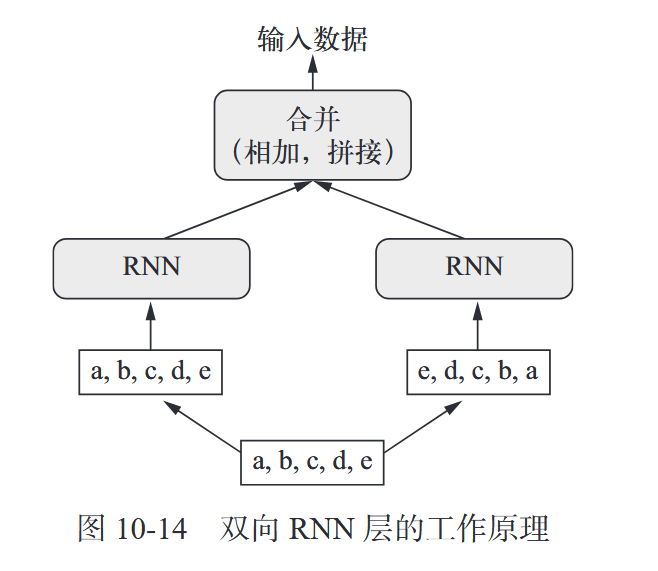